# **PREDICTIVE MODELLING PROJECT - a casestudy on OTT Media service**

## **Problem Statement**

**Context:**

An over-the-top (OTT) media service is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including existing series acquired from other producers, as well as original content produced specifically for the service. They are typically accessed via websites on personal computers, apps on smartphones and tablets, or televisions with integrated Smart TV platforms.

Presently, OTT services are at a relatively nascent stage and are widely accepted as a trending technology across the globe. With the increasing change in customers' social behavior, which is shifting from traditional subscriptions to broadcasting services and OTT on-demand video and music subscriptions every year, OTT streaming is expected to grow at a very fast pace. The global OTT market size was valued at USD 121.61 billion in 2019 and is projected to reach $1,039.03 billion by 2027, growing at a CAGR of 29.4% from 2020 to 2027. The shift from television to OTT services for entertainment is driven by benefits such as on-demand services, ease of access, and access to better networks and digital connectivity.

With the outbreak of COVID-19, OTT services are striving to meet the growing entertainment appetite of viewers, with some platforms already experiencing a 46% increase in consumption and subscriber count as viewers seek fresh content. With innovations and advanced transformations, which will enable the customers to access everything they want in a single space, OTT platforms across the world are expected to increasingly attract subscribers on a concurrent basis.


**Objective:**

ShowTime is an OTT service provider and offers a wide variety of content (movies, web shows, etc.) for its users. They want to determine the driver variables for first-day content viewership so that they can take necessary measures to improve the viewership of the content on their platform. Some of the reasons for the decline in viewership of content would be the decline in the number of people coming to the platform, decreased marketing spend, content timing clashes, weekends and holidays, etc. They have hired you as a Data Scientist, shared the data of the current content on their platform, and asked you to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.



**Data Description:**
The data contains the different factors to analyze for the content. The detailed data dictionary is given below.

**Data Dictionary:**
- visitors: Average number of visitors, in millions, to the platform in the past week
- ad_impressions: Number of ad impressions, in millions, across all ad - campaigns for the content (running and completed)
- major_sports_event: Any major sports event on the day
- genre: Genre of the content
- dayofweek: Day of the release of the content
- season: Season of the release of the content
- views_trailer: Number of views, in millions, of the content trailer
- views_content: Number of first-day views, in millions, of the content

**The following questions need to be answered as part of the EDA section of the project:**

1. What does the distribution of content views look like?
2. What does the distribution of genres look like?
3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?
5. How does the viewership vary with the season of release?
6. What is the correlation between trailer views and content views?

**Point:** Analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.

## **Importing the libraries and data**

In [177]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression

In [178]:
# Loading the drive
from google.colab import drive # importing/linking the google drive with google colab.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Loading:**

In [230]:
# Loading and displaying the data

path="/content/drive/My Drive/ottdata.csv" # Loading the dataset 'ottdata.csv' as csv file into google colab.
data = pd.read_csv(path) # Reading the dataset
data.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


Observations:
- The dataset contains information about OTT Content.
- Data is checked with trailer views and content views and an analysis based on the season and genre is done.

In [231]:
data.shape # Checking the rows and columns count

(1000, 8)

- The data contains 8 attributes and 1000 observations.

In [232]:
data.info() # Checking the data types of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


 - There are 3 categorical varibles and 5 numerical variables in the data
 - The target variable is views_content of ottdata which is float type.

In [182]:
unique_counts = data.nunique() # Checking the unique values
unique_counts

,0
visitors,56
ad_impressions,80
major_sports_event,2
genre,8
dayofweek,7
season,4
views_trailer,799
views_content,61


##**Statistical Analysis of data**

In [183]:
data.describe().T # Checking the statistical information about the data

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
major_sports_event,1000.0,0.40000,0.490143,0.00,0.0000,0.00,1.000,1.00
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


- statistical summary of five key variables ie., visitors, ad impressions, major sports event, views trailer, and views content is shown.
- The average number is 1.70 with a standard deviation of 0.23.
- Higher visitor counts seem to coincide with higher ad impressions, suggesting that increased foot traffic leads to more ad views.
- Trailer views vary significantly from 30.08 to 199.92, suggesting that certain trailers pull more viewership.

## **Exploratory data analysis:** : The detailed EDA can be found in the <a href = #link1>appendix section</a>.

In [184]:
# Analysis  of views_content variable by defining a histplot and boxplot in one function
def histogram_boxplot(data, column, figsize=(15,10), kde = True, bins = None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default True)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box, ax_hist) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,)  # creating the 2 subplots

    sns.boxplot(data=data, x=column, ax=ax_box, showmeans=True, color="violet")# boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(data=data, x=column, kde=kde, ax=ax_hist, bins=bins, palette="winter") if bins else sns.histplot(
        data=data, x=column, kde=kde, ax=ax_hist)

    ax_hist.axvline(data[column].mean(), color="green", linestyle="--")  # Add mean to the histogram
    ax_hist.axvline(data[column].median(), color="black", linestyle="-")  # Add median to the histogram


In [185]:
# Defining a countplot and barplot together in one function
def countplot_boxplot(data, column,figsize = (10,15)):
    """
    Function to create both a countplot and a boxplot for a categorical column.
    Parameters:
    df (DataFrame): Data source
    column (str): Column name
    figsize (tuple): Figure size
    """
    # Create subplots
    fig, (ax_count, ax_box) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.3, 0.7)},
        figsize=figsize    )

    # Countplot (frequency of categories)
    sns.countplot(data=data, x=column, ax=ax_count, color="violet")
    # Adding counts on top of bars
    for p in ax_count.patches:
        ax_count.annotate(f'{int(p.get_height())}',
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax_count.set_title(f"Countplot of {column}")

    # Boxplot (distribution of numerical values across categories)
    sns.boxplot(data=data, x=column, y=data["views_content"], ax=ax_box, hue=column, palette="winter")
    ax_box.set_title(f"Boxplot of Views Content by {column}")
    plt.show()

##**Data Preprocessing:**

In [186]:
df=data.copy()

In [187]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

 - There are no duplicates in the data.

In [188]:
# Checking for missing values
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


 - There are no missing values in the data.

### Feature engineering and One-hot encoding:

In [189]:
#Feature engineering by encoding Categorical Variables

# Converting genre, dayofweek, and season into numerical representations using one-hot encoding or label encoding.
df = pd.get_dummies(df, columns=["genre", "dayofweek", "season"], drop_first=True)


# Convert major_sports_event into a binary feature (already exists as 0 and 1).
df["major_sports_event"] = df["major_sports_event"].astype(int)

### Outlier detection and treatment:

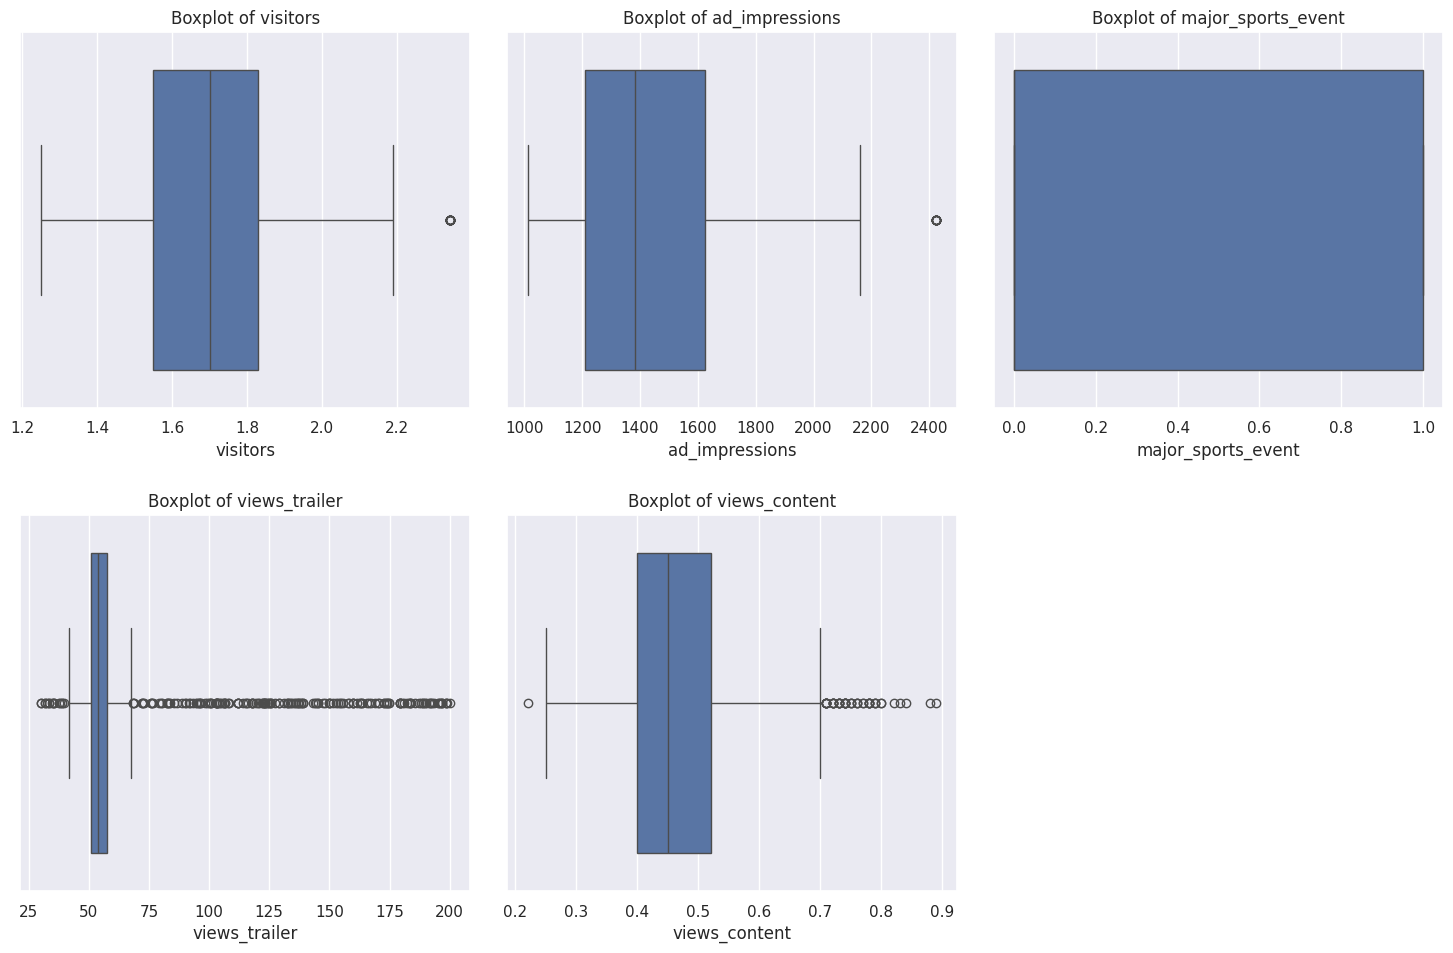

In [190]:
# Outliers Detection:

# Selecting numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Creating boxplots for each numerical feature
plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot((len(num_cols) // 3) + 1, 3, i + 1)  # Adjusting subplot layout dynamically
    sns.boxplot(data=df, x=variable)
    plt.tight_layout(pad=2)
    plt.title(f"Boxplot of {variable}")

plt.show()

**Outlier treatment:**
- There are quite a few outliers in the data
- However, we will not treat them as they are proper values

## **Data preparation for modelling**

In [191]:
#Defining x and y variables
X = df.drop(columns=['views_content'])  # Assuming this is the target variable
y = df['views_content']
print(X.head())
print(y.head())

   visitors  ad_impressions  major_sports_event  views_trailer  genre_Comedy  \
0      1.67         1113.81                   0          56.70         False   
1      1.46         1498.41                   1          52.69         False   
2      1.47         1079.19                   1          48.74         False   
3      1.85         1342.77                   1          49.81         False   
4      1.46         1498.41                   0          55.83         False   

   genre_Drama  genre_Horror  genre_Others  genre_Romance  genre_Sci-Fi  \
0        False          True         False          False         False   
1        False         False         False          False         False   
2        False         False         False          False         False   
3        False         False         False          False          True   
4        False         False         False          False          True   

   genre_Thriller  dayofweek_Monday  dayofweek_Saturday  dayofweek_S

In [192]:
# let's add the intercept to data
X = sm.add_constant(X)

In [193]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0,56.70,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.0,1.46,1498.41,1,52.69,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.0,1.47,1079.19,1,48.74,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.0,1.85,1342.77,1,49.81,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1.46,1498.41,0,55.83,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [194]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,visitors,ad_impressions,major_sports_event,views_trailer,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,0.0,56.70,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.46,1498.41,1.0,52.69,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.47,1079.19,1.0,48.74,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.85,1342.77,1.0,49.81,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.46,1498.41,0.0,55.83,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [195]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [196]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


## **Model Building - Linear regression:**

In [197]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 15 Jun 2025   Prob (F-statistic):          1.32e-215
Time:                        16:13:19   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

### Interpreting the Regression Results:

1. **Adjusted. R-squared**: It reflects the fit of the model.
    - Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
    - In our case, the value for adj. R-squared is **0.788**, which is good.


2. ***const* coefficient**: It is the Y-intercept.
    - It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the *const* coefficient.
    - In our case, the value for `const` coefficient is **-0.2611**


3. **Coefficient of a predictor variable**: It represents the change in the output Y due to a change in the predictor variable (everything else held constant).
    - In our case, the coefficient of `visitors` is **0.1287**.

## Model performance check:

Let's check the performance of the model using different metrics.

- We will be using metric functions defined in sklearn for RMSE, MAE, and  R2 .

- We will define a function to calculate MAPE and adjusted  R2 .

- The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
- We will create a function which will print out all the above metrics in one go.

In [198]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [199]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.04853,0.038197,0.791616,0.785162,8.55644


In [200]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050603,0.040782,0.766447,0.748804,9.030464


**Observations**

- The training $R^2$ is 0.79, so the model is not underfitting

- The train and test RMSE and MAE are comparable, so the model is not overfitting either

- MAE suggests that the model can predict ottdata within a mean error of 0.04 on the test data

- MAPE of 9.03 on the test data means that we are able to predict within ~9% of the ottdata.

### Checking Linear Regression Assumptions

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR MULTICOLLINEARITY

* Multicollinearity occurs when predictor variables in a regression model are correlated which is a problem because predictor variables should be independent. If the correlation between variables is high, it can cause problems when we fit the model and interpret the results.

* One way to test it is by using the Variance Inflation Factor, or VIF.

* **Variance  Inflation Factor (VIF)**:  Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors.

* **General Rule of thumb**:
    - If VIF is between 1 and 5, then there is low multicollinearity.
    - If VIF is between 5 and 10, we say there is moderate multicollinearity.
    - If VIF is exceeding 10, it shows signs of high multicollinearity.

Let's define a function to check VIF.

In [201]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif
checking_vif(x_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,major_sports_event,1.065689
4,views_trailer,1.023551
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


* There are two columns `views_trailer` and `views_trailer_transformed` which show high multicolinearity which is VIF > 5, hence we can drop these columns.

### Multicolinearity: To remove multicollinearity

1. Drop every column one by one that has a VIF score greater than 5.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 5.

Let's define a function that will help us do this.

In [202]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

In [203]:
col_list = ["views_trailer", "views_trailer_transformed"]

res = treating_multicollinearity(x_train, y_train, col_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,views_trailer_transformed,0.785478,0.049275
1,views_trailer,0.224159,0.093708


In [204]:
col_to_drop = "views_trailer_transformed"
x_train2 = x_train.loc[:, ~x_train.columns.str.startswith(col_to_drop)]
x_test2 = x_test.loc[:, ~x_test.columns.str.startswith(col_to_drop)]

# Check VIF now
vif = checking_vif(x_train2)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  views_trailer_transformed


,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,major_sports_event,1.065689
4,views_trailer,1.023551
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


 - We have dealt with multicollinearity in the data
 - Let's rebuild the model using the updated set of predictors variables

In [205]:
olsmod1 = sm.OLS(y_train, x_train2).fit()
print(olsmod1.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 15 Jun 2025   Prob (F-statistic):          1.32e-215
Time:                        16:13:21   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0602    

**Observations**

- We can see that adj. R-squared has dropped from 0.788 to 0.785, which shows that the dropped columns did not have much effect on the model
- As there is no multicollinearity, we can look at the p-values of predictor variables to check their significance

### Dealing with high p-value variables

- Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them
- But sometimes p-values change after dropping a variable. So, we will not drop all variables at once
- Instead, we will do the following:
    - Build a model, check the p-values of the variables, and drop the column with the highest p-value
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value
    - Repeat the above two steps till there are no columns with p-value > 0.05


In [206]:
# initial list of columns
predictors = x_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'visitors', 'major_sports_event', 'views_trailer', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [207]:
x_train3 = x_train2[selected_features]
x_test3 = x_test2[selected_features]

In [208]:
olsmod2 = sm.OLS(y_train, x_train3).fit()
print(olsmod2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sun, 15 Jun 2025   Prob (F-statistic):          7.03e-224
Time:                        16:13:22   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

In [209]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmod2_train_perf = model_performance_regression(olsmod2, x_train3, y_train)
olsmod2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [210]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmod2_test_perf = model_performance_regression(olsmod2, x_test3, y_test)
olsmod2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097


**Observations**

* P values > 0.05 are now addressed. so we'll consider the features in *x_train3* as the final set of predictor variables and *olsmod2* as the final model.
* The adjusted R-squared is 0.786, i.e., our model is able to explain ~78.6% of the variance
* The adjusted R-squared in *olsmod1* (where we considered the variables without multicollinearity) was 0.785
* This shows that the variables we dropped were not affecting the model
* RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting

**Now we'll check the rest of the assumptions on *olsmod2*.**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE

**Why the test?**

* Linearity describes a straight-line relationship between two variables, predictor variables must have a linear relation with the dependent variable.

**How to check linearity and independence?**

- Make a plot of fitted values vs residuals.
- If they don't follow any pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.


In [211]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmod2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmod2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.445434,-0.045434
716,0.70,0.677403,0.022597
640,0.42,0.433999,-0.013999
804,0.55,0.562030,-0.012030
737,0.59,0.547786,0.042214


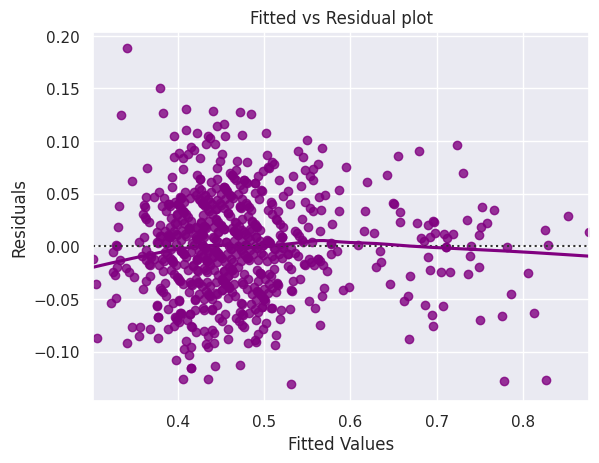

In [212]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

* The scatter plot shows the distribution of residuals (errors) vs fitted values (predicted values).
* **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

### TEST FOR NORMALITY

* Residuals, should be normally distributed. Non-normality suggests that there are a few unusual data points that must be studied closely to make a better model.
* Histogram, Q-Qplot and a Shapiro-wilk's test help understand the normality of the data.

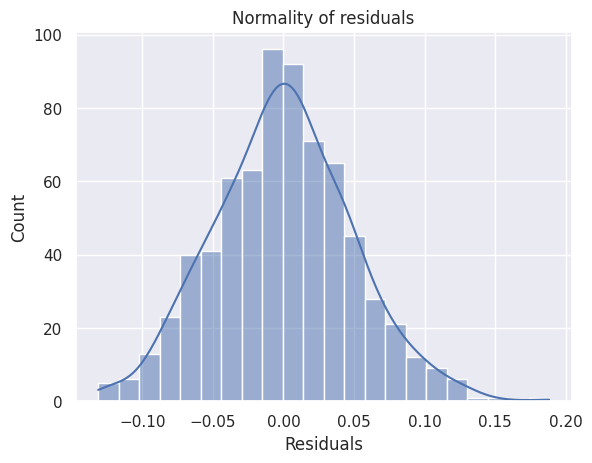

In [213]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

- The histogram of residuals have a bell shape and slightly right skewed.
- Let's check the Q-Q plot.

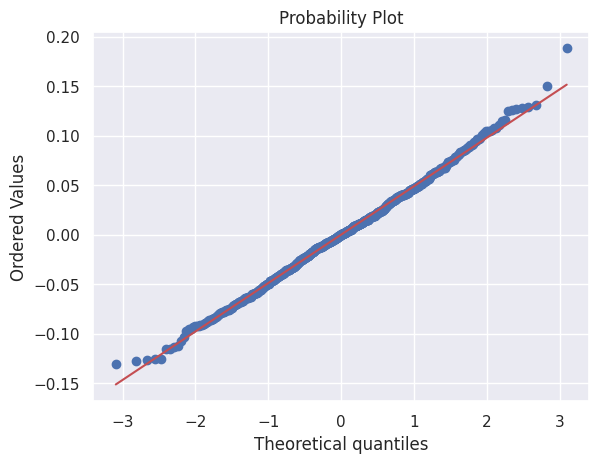

In [214]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

- The residuals more or less follow a straight line except for the tails.
- Let's check the results of the Shapiro-Wilk test.

Null and alternative hypothesis for Shapiro-Wilks test:
- Null hypothesis: Residuals are normally distributed
- Alternate hypothesis: Residuals are not normally distributed

In [215]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9973155427169242), pvalue=np.float64(0.31085896470071894))

- Since p = 0.3109 is greater than 0.05, fail to reject H₀, hence residuals are likely normally distributed
- **So, the Normality assumption is satisfied.**

### TEST FOR HOMOSCEDASTICITY
If the variance of the residuals is symmetrically distributed across the regression line, then the data is said to be homoscedastic.

* The residual vs fitted values plot can be looked at to check for homoscedasticity.

In [216]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)
lzip(name, test)

[('F statistic', np.float64(1.1313612904200752)),
 ('p-value', np.float64(0.12853551819087372))]

**Since p-value > 0.05, we can say that the residuals are homoscedastic. So, this assumption is satisfied.**

## Predictions on test data:

- Now that we have checked all the assumptions of linear regression and they are satisfied, let's go ahead with prediction.

In [217]:
# predictions on the test set
pred = olsmod2.predict(x_test3)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.434802
194,0.51,0.500314
314,0.48,0.430257
429,0.41,0.492544
267,0.41,0.487034
746,0.68,0.680000
186,0.62,0.595078
964,0.48,0.503909
676,0.42,0.490313
320,0.58,0.560155


- We can observe here that our model has returned pretty good prediction results, and the actual and predicted values are comparable

## Final Model

In [ ]:
x_train_final = x_train3.copy()
x_test_final = x_test3.copy()

In [218]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sun, 15 Jun 2025   Prob (F-statistic):          7.03e-224
Time:                        16:13:29   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0747    

In [219]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [220]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test_final, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097


* The model is able to explain ~78% of the variation in the data

* The train and test RMSE and MAE are low and comparable. So, our model is not suffering from overfitting

* The MAPE on the test set suggests we can predict within 9.17% of the anime ratings

* Hence, we can conclude the model *olsmodel_final* is good for prediction as well as inference purposes

## **Conclusions and Recommendations**

1. The model is able to explain ~78% of the variation in the data and within 9.17% of the ott data on the test data, this indicates that the model is good for prediction as well as inference purposes

2. If the number of visitors increases by one unit, then its ottcontent views increases by 0.1287 units, all other variables held constant

3. If the sports event increases by one unit, then its content vieweship decreases by 0.0606 units, all other variables held constant. Hence this event should be considered while releasing new content.

4. Since the content views on saturday are high, it is preferable to release more content on this day.

5. As the ottviews increase with an increase in the number of people watching it, the company can consider better marketing strategies to reach more audience.

6. Since the content views are more in summer season, hence better and more content can be launched during this season.


## **Key Questions and answers:**

###Key questions 1: What does the distribution of content views look like?

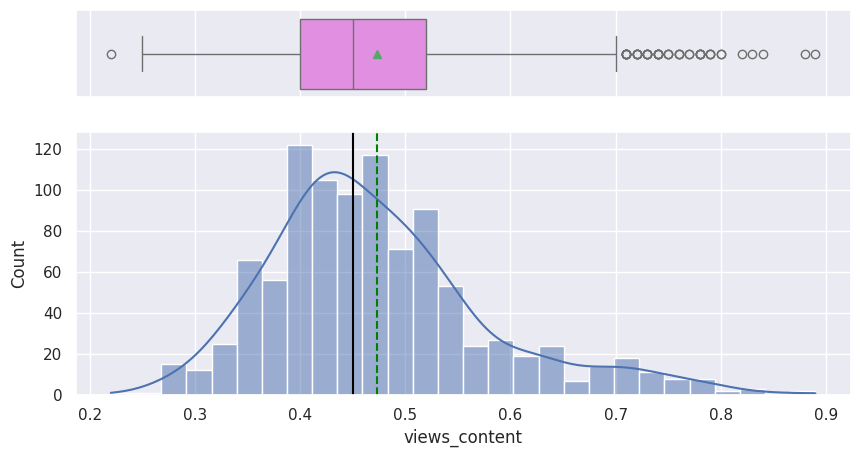

In [221]:
histogram_boxplot(df, "views_content", figsize=(10,5))

### **Ans:**
- The distribution of views content looks like a right_skewed data which indicates that first day views of some content are extremely high which is pulling the average while most of the other data points are low.
- This indicates that some content or show is more popular having better views than other
- Data looks like almost a bell curve but right skewed to some extent.

### Key questions 2: What does the distribution of genres look like?


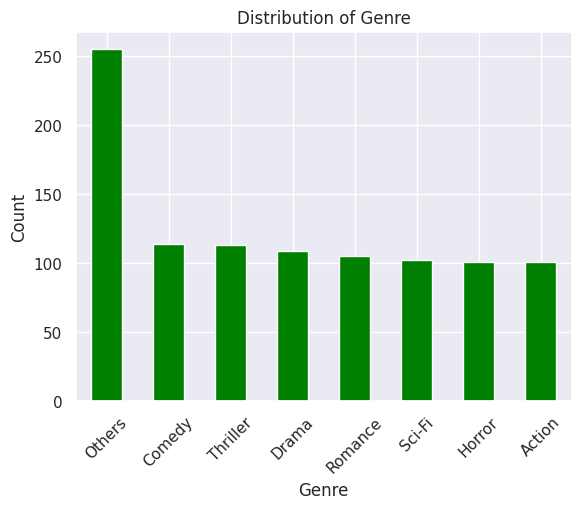

In [222]:
# creating a histogram of Genre
data["genre"].value_counts().plot(kind="bar", color="green")
plt.title("Distribution of Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


### **Ans:**

- It shows a right skewed data which infers content in genre-'others' has more views

### Key question 3: The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?

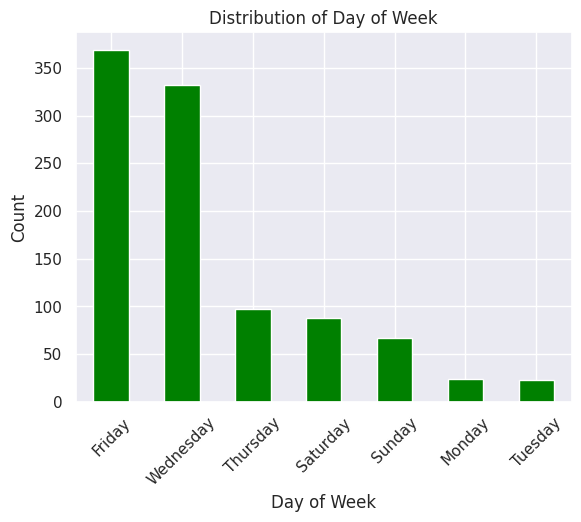

In [233]:
# Checking how viewership vary with day of release by using the featuring engineering on dayofweek column

data["dayofweek"].value_counts().plot(kind="bar", color="green")
plt.title("Distribution of Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


### **Ans:**

- First graph indicates that the weekends are the peakdays attracting higher views compared to weekdays.
- When looked at each day in the second graph, it states a wednesday and friday attracts better views compared to other days.


### Key question 4: How does the viewership vary with the season of release?

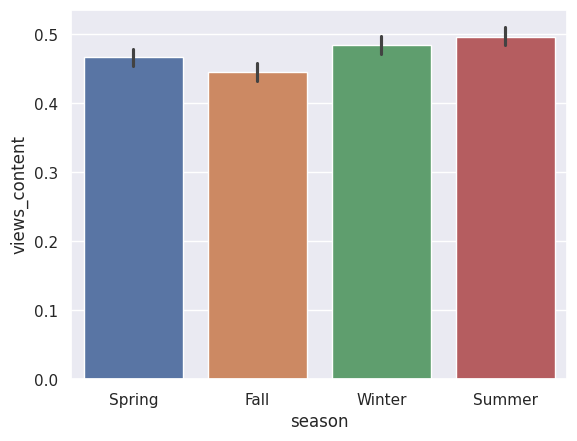

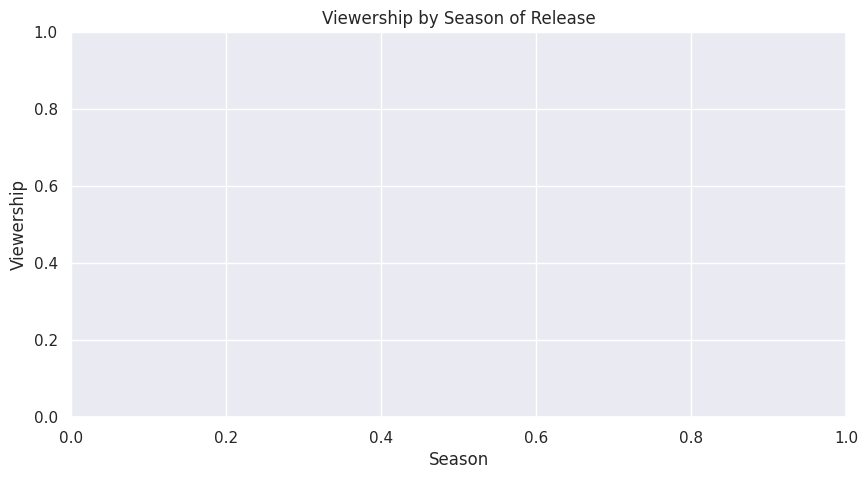

In [237]:
sns.barplot(data=data, x="season", y="views_content",hue = "season")
plt.figure(figsize=(10, 5))
plt.title("Viewership by Season of Release")
plt.xlabel("Season")
plt.ylabel("Viewership")
plt.show()


### **Ans:**
- Summer attracts more viewers compared to anyother seasons.
- There is no significant fluctuations in the viewership when compared amongst the seasons.


### Key question 5: What is the correlation between trailer views and content views?

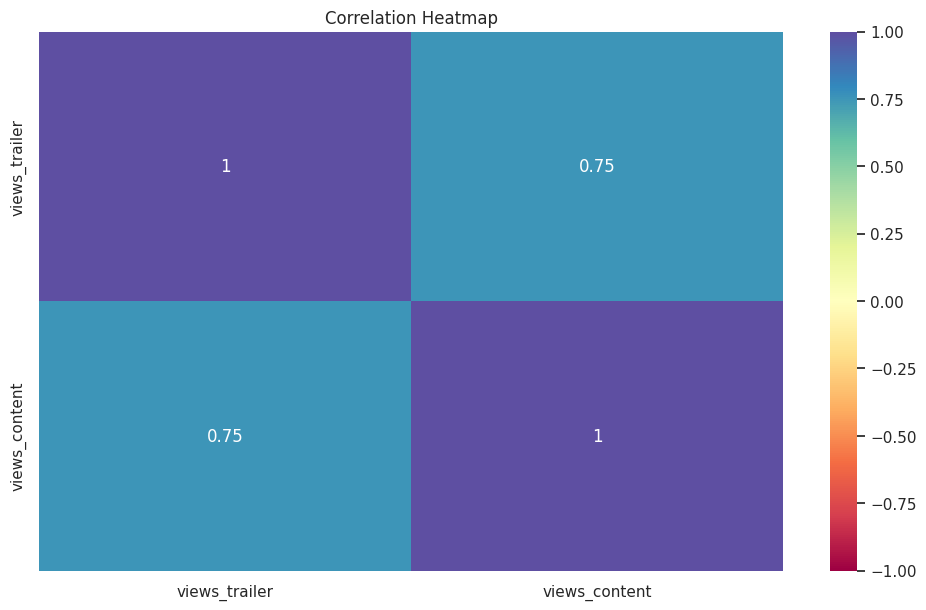

In [229]:
# Plotting a heat map to understand the correlation between trailer views and content views
plt.figure(figsize=(12, 7))
sns.heatmap(df[["views_trailer", "views_content"]].corr(), annot=True, vmin=-1, vmax=1, cmap="Spectral")
plt.title("Correlation Heatmap")
plt.show()

**Ans:**

- The above heatmap reveals a strong correlation between trailer views and content views, as it shows a 0.75 correlation which is nearer to 1.

1. We want to analyze the data and come up with a linear regression model to determine the driving factors for first-day viewership.

2. Before we proceed to build a model, we'll have to encode categorical features.

3. We'll split the data into train and test to be able to evaluate the model that we build on the train data.

4. We will build a Linear Regression model using the train data and then check it's performance.

# <a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

### Univariate analysis of numerical variables:

Text(0.5, 1.0, 'Distribution of views_trailer')

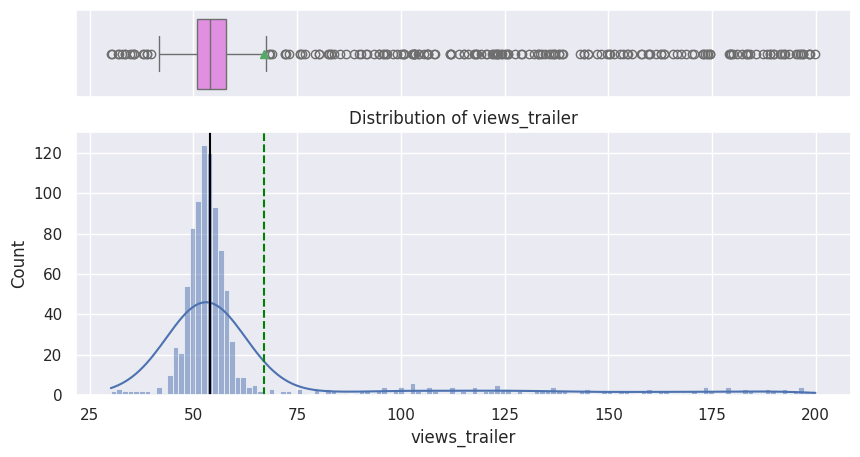

In [ ]:
histogram_boxplot(df, "views_trailer", figsize=(10,5))
plt.title("Distribution of views_trailer")

- Data is heavily right skewed with extreme outliers in it.

Text(0.5, 1.0, 'Distribution of ad_impressions')

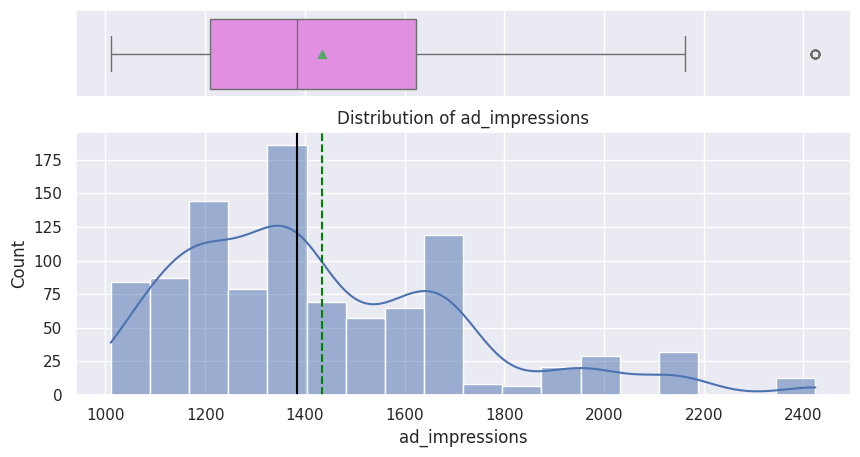

In [ ]:
histogram_boxplot(df, "ad_impressions", figsize=(10,5))
plt.title("Distribution of ad_impressions")

•	Data is heavily right skewed with one outlier in it.


Text(0.5, 1.0, 'Distribution of visitors')

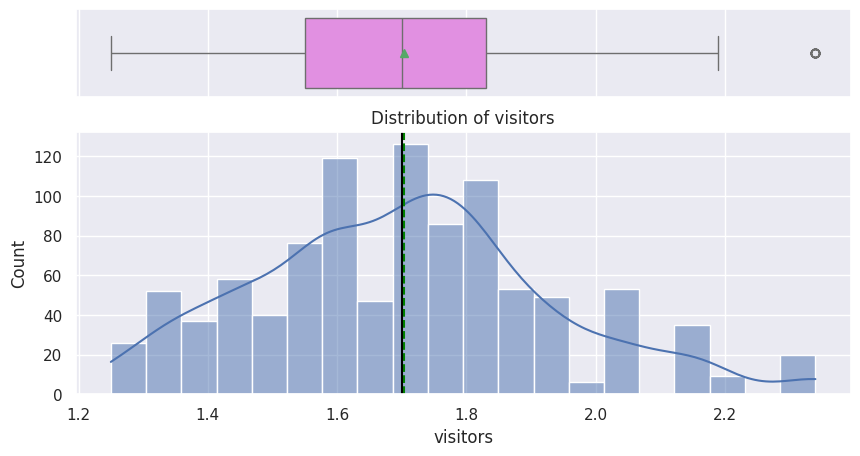

In [ ]:
histogram_boxplot(df, "visitors", figsize=(10,5))
plt.title("Distribution of visitors")

- Data seems a almost normally distributed data with only one outlier datapoint.

### Univariate analysis of Categorical variables:

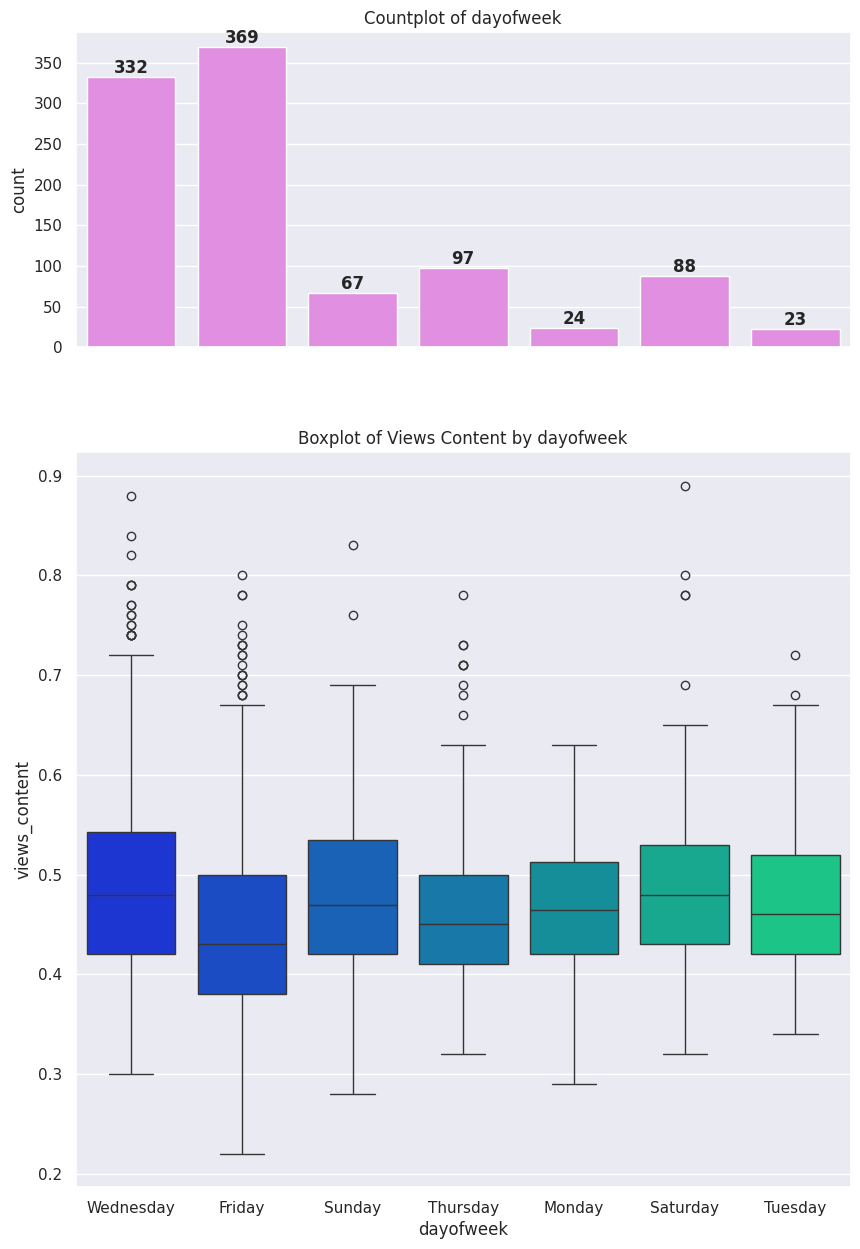

In [ ]:
countplot_boxplot(df, "dayofweek")

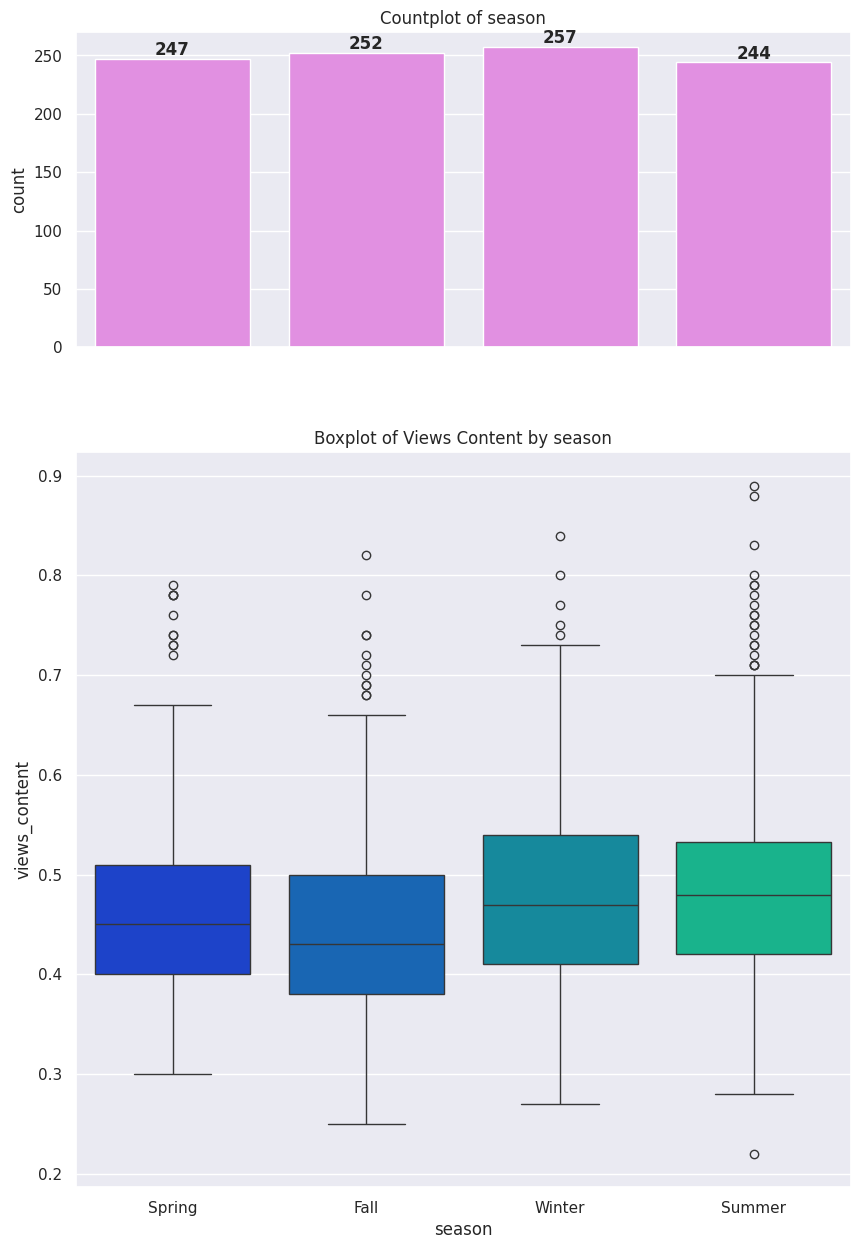

In [ ]:
countplot_boxplot(df, "season")

### Bivariate analysis:

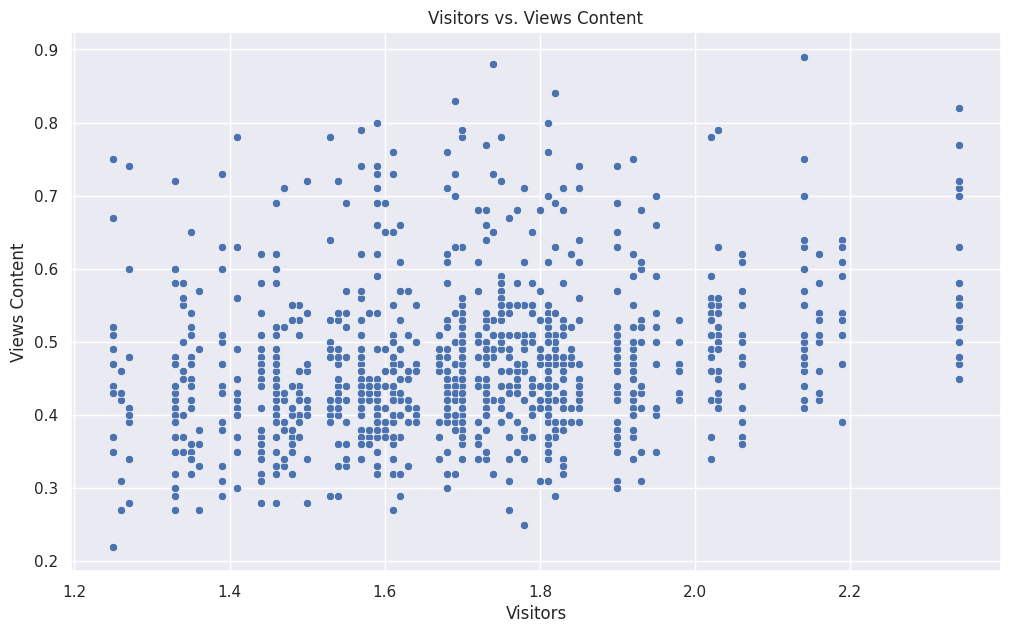

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x="visitors", y="views_content") # Analysis of visitors by views content
plt.title("Visitors vs. Views Content")
plt.xlabel("Visitors")
plt.ylabel("Views Content")
plt.show()

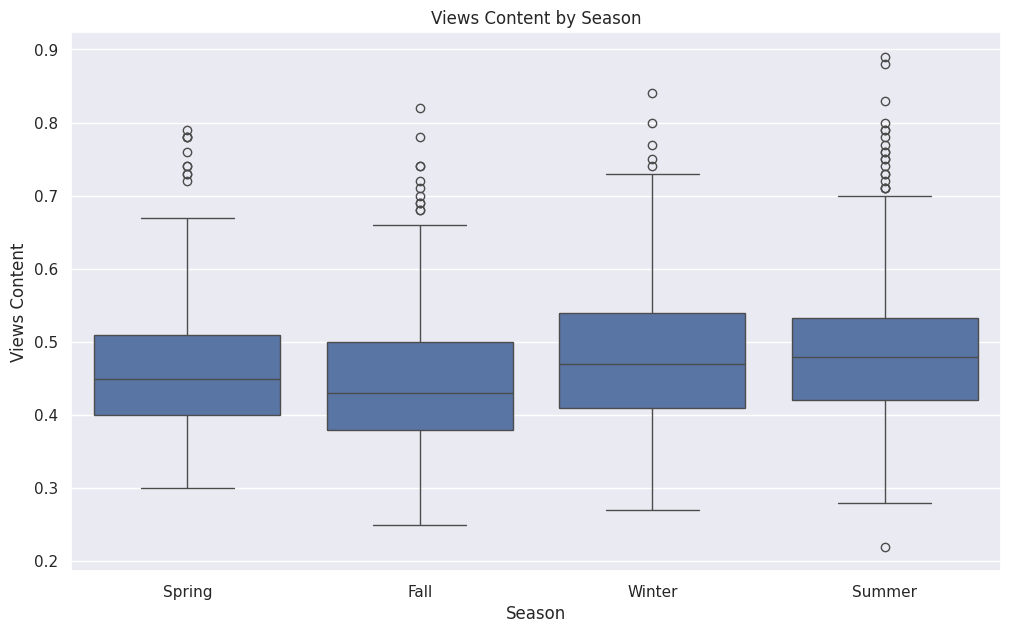

In [239]:
# Boxplot for categorical variables:
plt.figure(figsize=(12, 7))
sns.boxplot(data=data, x="season", y="views_content")
plt.title("Views Content by Season")
plt.xlabel("Season")
plt.ylabel("Views Content")
plt.show()

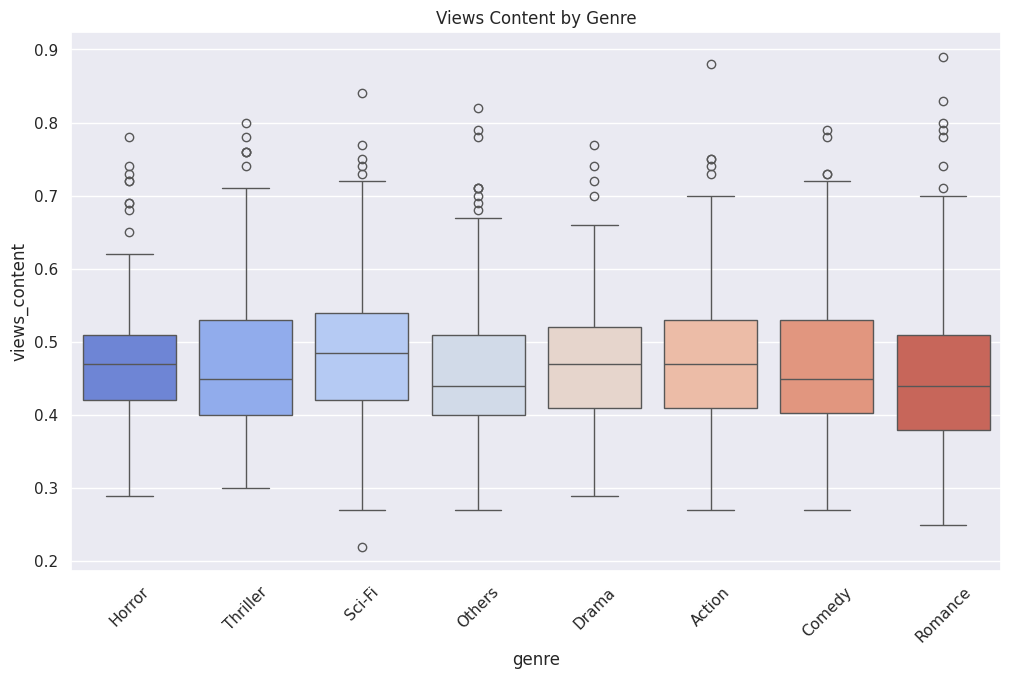

In [ ]:
# Comparing the views across different Genres.
plt.figure(figsize=(12, 7))
sns.boxplot(data=data, x="genre", y="views_content", palette="coolwarm",hue = "genre")
plt.xticks(rotation=45)
plt.title("Views Content by Genre")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Horror'),
  Text(1, 0, 'Thriller'),
  Text(2, 0, 'Sci-Fi'),
  Text(3, 0, 'Others'),
  Text(4, 0, 'Drama'),
  Text(5, 0, 'Action'),
  Text(6, 0, 'Comedy'),
  Text(7, 0, 'Romance')])

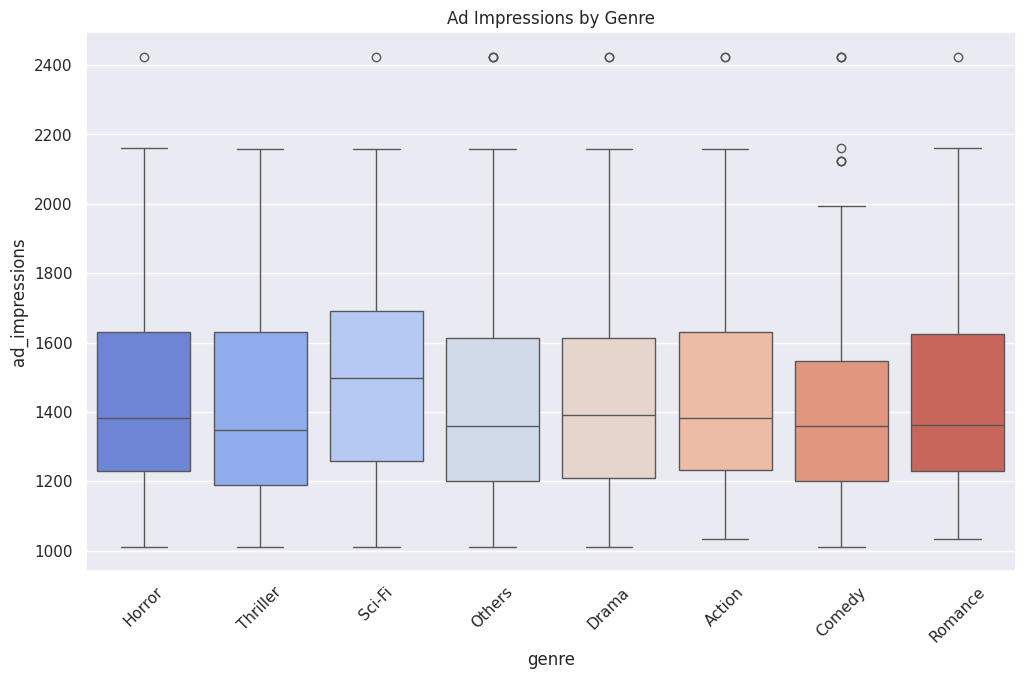

In [240]:
# Comparing the ad impressions across different Genres.
plt.figure(figsize=(12, 7))
sns.boxplot(data=data, x="genre", y="ad_impressions", palette="coolwarm",hue = "genre")
plt.title("Ad Impressions by Genre")
plt.xticks(rotation=45)

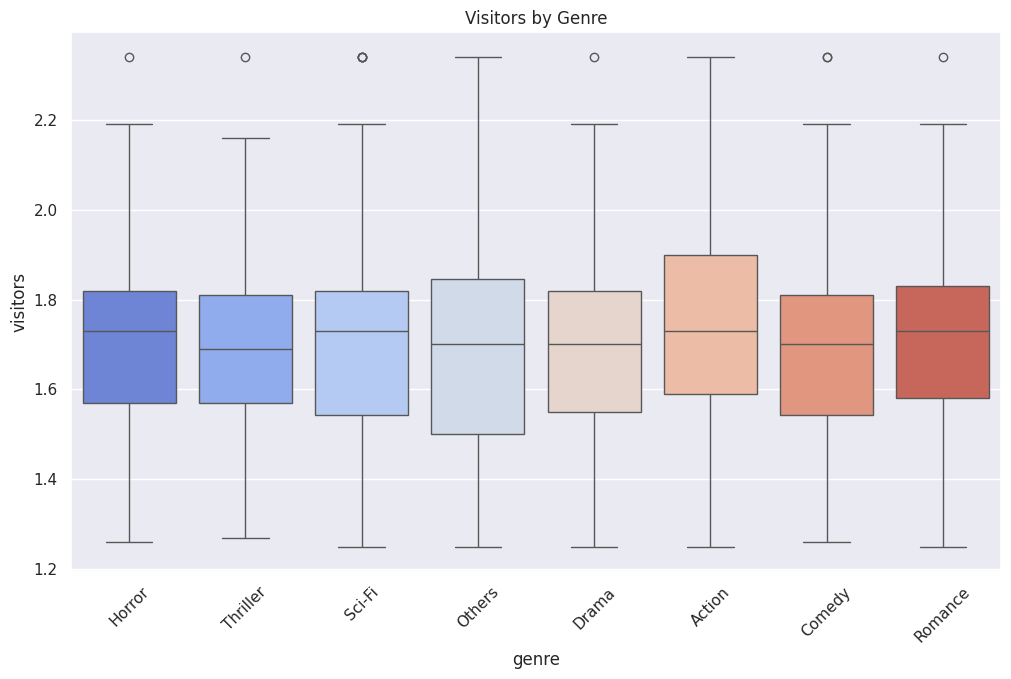

In [241]:
# Comparing the visitors across different Genres.
plt.figure(figsize=(12, 7))
sns.boxplot(data=data, x="genre", y="visitors", palette="coolwarm",hue = "genre")
plt.xticks(rotation=45)
plt.title("Visitors by Genre")
plt.show()